In [ ]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
data = load_breast_cancer()

X = data.data
y = data.target

# Convert to DataFrame (for better understanding)
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(probability=True)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Logistic Regression
Accuracy: 0.9736842105263158
Precision: 0.9722222222222222
Recall: 0.9859154929577465
F1 Score: 0.9790209790209791
Confusion Matrix:
 [[41  2]
 [ 1 70]]

Decision Tree
Accuracy: 0.9385964912280702
Precision: 0.9444444444444444
Recall: 0.9577464788732394
F1 Score: 0.951048951048951
Confusion Matrix:
 [[39  4]
 [ 3 68]]

Random Forest
Accuracy: 0.9649122807017544
Precision: 0.958904109589041
Recall: 0.9859154929577465
F1 Score: 0.9722222222222222
Confusion Matrix:
 [[40  3]
 [ 1 70]]

SVM
Accuracy: 0.9824561403508771
Precision: 0.9726027397260274
Recall: 1.0
F1 Score: 0.9861111111111112
Confusion Matrix:
 [[41  2]
 [ 0 71]]


In [ ]:
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score"
])

print("\nFinal Results:")
print(results_df)


Final Results:
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.973684   0.972222  0.985915  0.979021
1        Decision Tree  0.938596   0.944444  0.957746  0.951049
2        Random Forest  0.964912   0.958904  0.985915  0.972222
3                  SVM  0.982456   0.972603  1.000000  0.986111


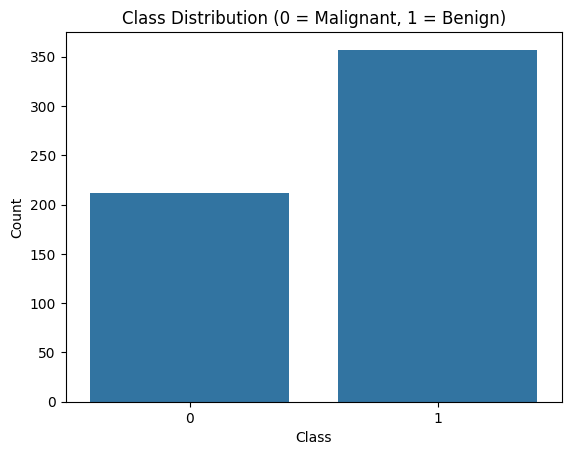

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count plot
sns.countplot(x=y)
plt.title("Class Distribution (0 = Malignant, 1 = Benign)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

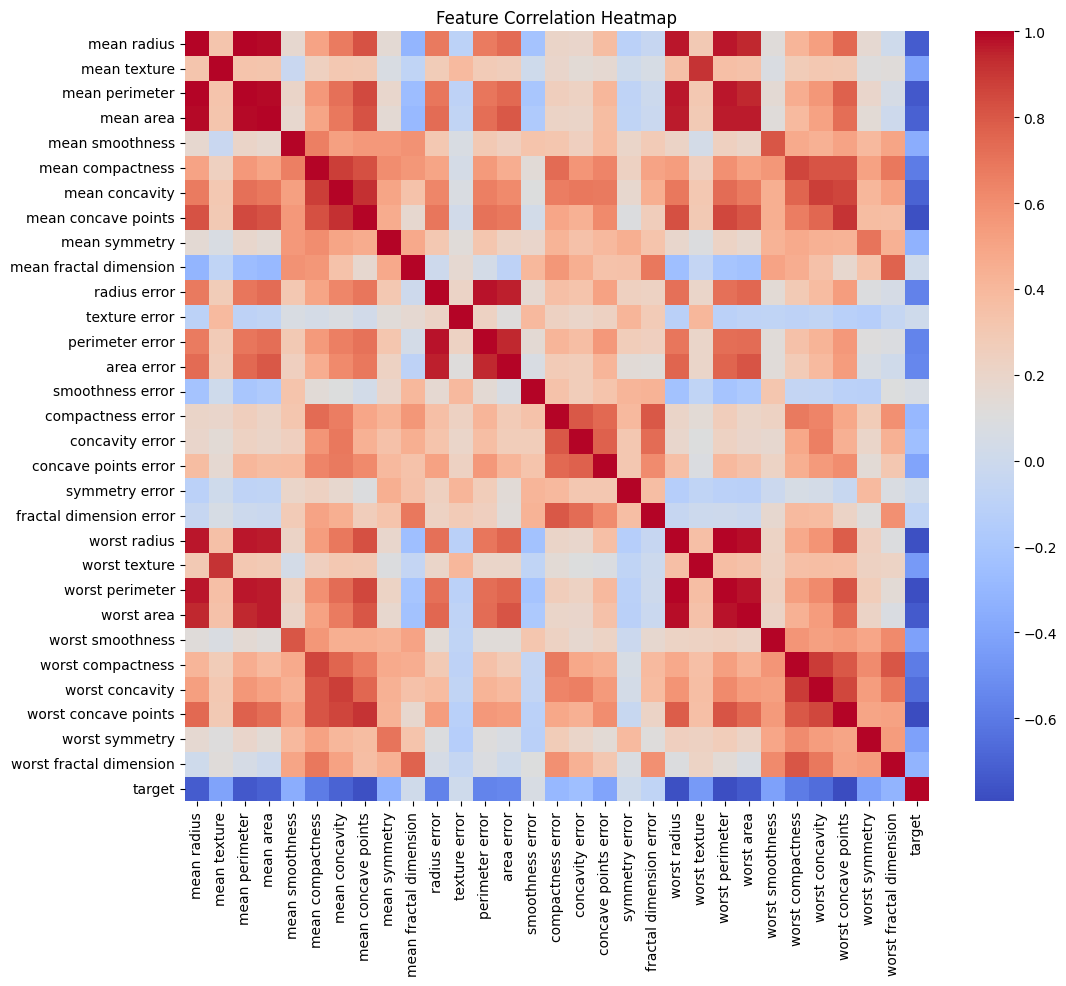

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


Logistic Regression


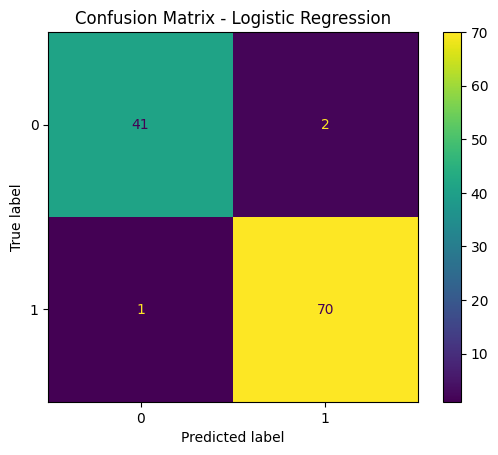


Decision Tree


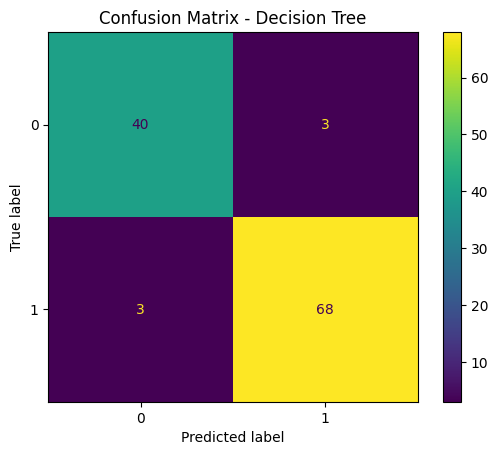


Random Forest


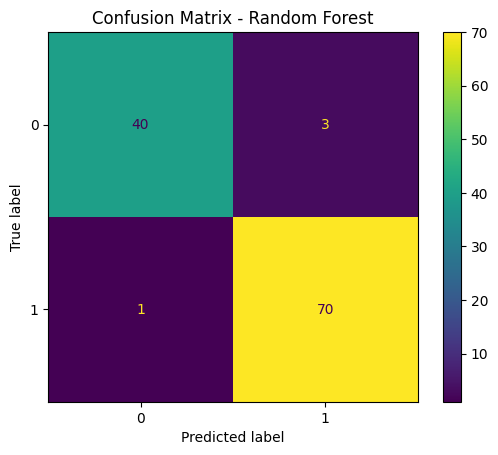


SVM


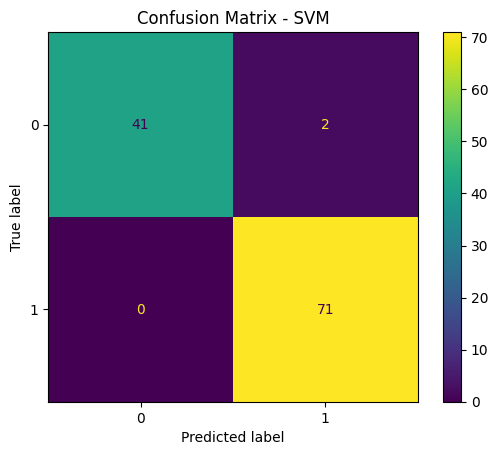

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name}")

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

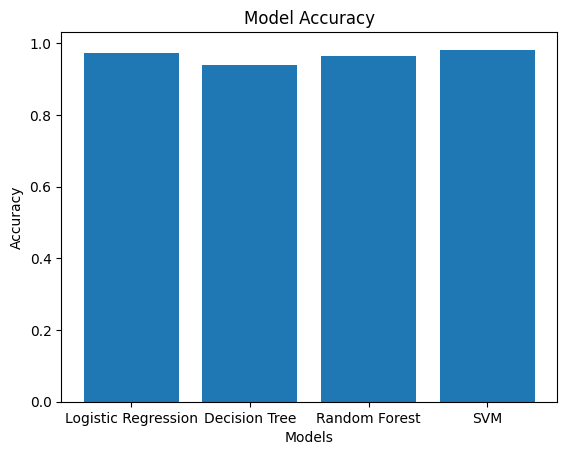

In [ ]:
# Extract values
model_names = results_df["Model"]
accuracies = results_df["Accuracy"]

plt.figure()
plt.bar(model_names, accuracies)
plt.title("Model Accuracy")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

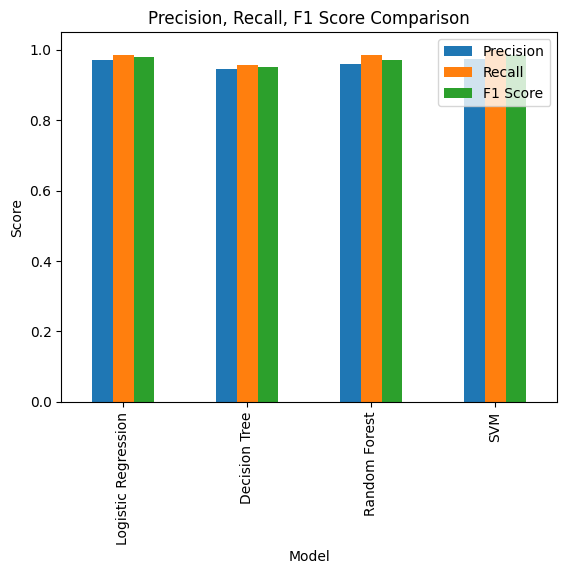

In [ ]:
results_df.set_index("Model")[["Precision", "Recall", "F1 Score"]].plot(kind='bar')

plt.title("Precision, Recall, F1 Score Comparison")
plt.ylabel("Score")
plt.show()

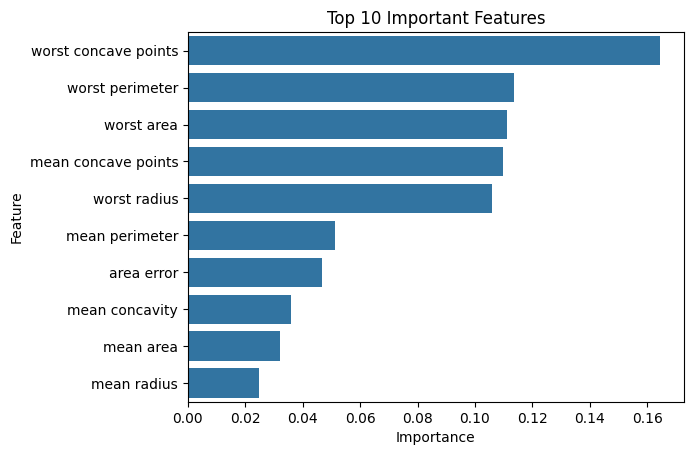

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)

importances = rf_model.feature_importances_

feature_names = data.feature_names

feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot top 10
plt.figure()
sns.barplot(x="Importance", y="Feature", data=feat_df.head(10))
plt.title("Top 10 Important Features")
plt.show()

In [ ]:
from sklearn.svm import SVC

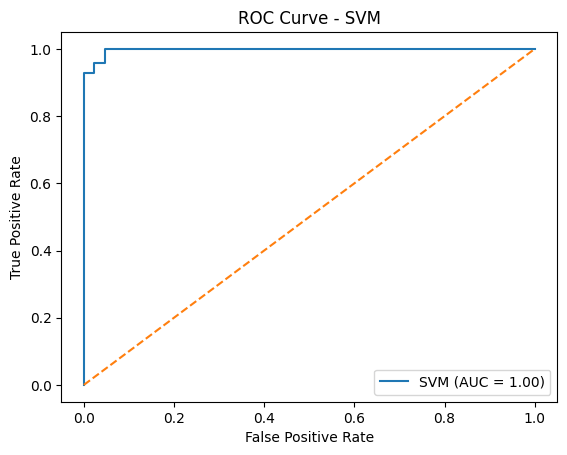

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Scaling (VERY IMPORTANT for SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (if not already done after scaling)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train SVM
svm_model = SVC(probability=True)
svm_model.fit(X_train, y_train)

# Get probabilities
y_prob = svm_model.predict_proba(X_test)[:,1]

# ROC calculation
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"SVM (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

# Assuming svm_model is the 'best_model' based on previous evaluations
scores = cross_val_score(svm_model, X_scaled, y, cv=5)
print("Cross-validation accuracy:", scores.mean())

SyntaxError: invalid decimal literal (2783705048.py, line 1)